# Random Neurons — Um Random Forest Malemolente

**Reconhecimento de Padrões e Aprendizado de Máquina**

Este notebook implementa o algoritmo **Random Neurons**, uma variante do Random Forest em que cada árvore é substituída por um classificador linear (Perceptron de Bolso) treinado sobre:

1. uma réplica bootstrap dos dados de treino; e
2. um subconjunto aleatório dos atributos (com cardinalidade $k$ também sorteada).

A classificação final é feita por **votação por maioria** entre os $L$ classificadores. Para lidar com problemas multiclasse, cada Perceptron de Bolso é estendido via estratégia **One-vs-Rest (OVR)**.

# Pipeline

- **(a)** Sortear $L$ réplicas $D_\ell$ por bootstrap;
- **(b)** Para cada $D_\ell$, sortear $k \in \{1,\dots,n\}$ e, em seguida, sortear $k$ índices sem repetição dentre os atributos;
- **(c)** Treinar um Perceptron de Bolso (OVR) sobre $D_\ell$ restrito aos $k$ atributos sorteados, com no máximo $M$ iterações;
- **(d)** Predição por voto majoritário dos $L$ classificadores.

Comparamos o desempenho contra o **Random Forest** do Scikit-Learn com o mesmo $L$, nos datasets **Iris** e **Wine**, variando $L \in \{5, 10, 25, 50, 100\}$ e $M \in \{10, 50, 200\}$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Perceptron de Bolso (*Pocket Perceptron*)

O Perceptron clássico de Rosenblatt não converge se os dados não forem linearmente separáveis — os pesos oscilam indefinidamente. O **Pocket Perceptron** (Gallant, 1990) resolve isso guardando *no bolso* o melhor vetor de pesos observado ao longo do treinamento, medido pelo número de classificações corretas no conjunto de treino.

Seja $\tilde{\mathbf{x}} = [\mathbf{x}^\top, 1]^\top$ o padrão com bias embutido e $\mathbf{w}$ o vetor de pesos. A regra de atualização, para um ponto $(\tilde{\mathbf{x}}_i, y_i)$ mal classificado com $y_i \in \{-1,+1\}$, é

$$ \mathbf{w} \leftarrow \mathbf{w} + y_i\, \tilde{\mathbf{x}}_i. $$

A cada iteração, se o novo $\mathbf{w}$ gerar menos erros do que o melhor já visto, ele é copiado para o "bolso".

In [ ]:
class PocketPerceptron:
    """Perceptron de Bolso binário (rótulos em {-1, +1})."""

    def __init__(self, max_iter=100, random_state=None):
        self.max_iter = max_iter
        self.random_state = random_state

    def _augment(self, X):
        # adiciona coluna de 1's para o bias
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def _errors(self, Xb, y, w):
        pred = np.sign(Xb @ w)
        pred[pred == 0] = 1
        return int(np.sum(pred != y))

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        Xb = self._augment(X)
        n_samples, dim = Xb.shape

        w = rng.standard_normal(dim) * 0.01   
        best_w = w.copy()
        best_err = self._errors(Xb, y, w)

        for _ in range(self.max_iter):
            preds = np.sign(Xb @ w); preds[preds == 0] = 1
            mis = np.where(preds != y)[0]
            if len(mis) == 0:                  
                best_w, best_err = w.copy(), 0
                break
            i = int(rng.choice(mis))          
            w = w + y[i] * Xb[i]               
            err = self._errors(Xb, y, w)
            if err < best_err:                
                best_err = err
                best_w = w.copy()

        self.w_ = best_w
        self.train_errors_ = best_err
        return self

    def decision_function(self, X):
        return self._augment(X) @ self.w_

    def predict(self, X):
        s = np.sign(self.decision_function(X))
        s[s == 0] = 1
        return s.astype(int)

## 2. Estratégia One-vs-Rest (OVR)

Para $c$ classes, treinamos $c$ Perceptrons de Bolso binários. O $k$-ésimo classificador trata a classe $k$ como positiva (+1) e todas as demais como negativas (−1). Na predição, escolhemos a classe cujo classificador produziu a maior *decision function* (maior margem):

$$ \hat{y}(\mathbf{x}) = \arg\max_{k \in \{1,\dots,c\}}\; \mathbf{w}_k^\top \tilde{\mathbf{x}}. $$

Isso dá, naturalmente, um critério de desempate entre classificadores que simultaneamente "reivindicam" o padrão.

In [3]:
class OVRPocket:
    """One-vs-Rest com Perceptron de Bolso como classificador base."""

    def __init__(self, max_iter=100, random_state=None):
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        rng = np.random.default_rng(self.random_state)
        self.models_ = []
        for c in self.classes_:
            y_bin = np.where(y == c, 1, -1).astype(int)
            seed = int(rng.integers(0, 2**31 - 1))
            clf = PocketPerceptron(max_iter=self.max_iter, random_state=seed).fit(X, y_bin)
            self.models_.append(clf)
        return self

    def predict(self, X):
        scores = np.column_stack([m.decision_function(X) for m in self.models_])
        return self.classes_[np.argmax(scores, axis=1)]

## 3. O ensemble RandomNeurons

Com os blocos acima, o ensemble é direto. Seguimos rigorosamente o roteiro (a)–(d):

- **fit**: gera $L$ réplicas bootstrap, sorteia $k$ e os atributos, e treina um `OVRPocket` em cada réplica.
- **predict**: faz cada componente votar e aplica voto majoritário.

In [ ]:
class RandomNeurons:
    """
    Ensemble de Perceptrons de Bolso (OVR) com bootstrap e seleção aleatória
    de atributos — análogo a um Random Forest em que as 'árvores' são
    classificadores lineares.

    Parâmetros
    ----------
    L : int
        Número de classificadores base.
    M : int
        Número máximo de iterações do Pocket Perceptron.
    random_state : int ou None
        Semente para reprodutibilidade.
    """

    def __init__(self, L=10, M=100, random_state=None):
        self.L = L
        self.M = M
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        m, n = X.shape
        rng = np.random.default_rng(self.random_state)

        self.classes_  = np.unique(y)
        self.models_   = []   # L classificadores OVR
        self.feat_idx_ = []   # índices de atributos de cada um

        for _ in range(self.L):
            # (a) bootstrap: amostra com reposição de tamanho m
            boot = rng.integers(0, m, size=m)
            X_b, y_b = X[boot], y[boot]

            # (b) k ~ U{1,...,n} e k índices sem repetição
            k = int(rng.integers(1, n + 1))
            feats = rng.choice(n, size=k, replace=False)
            feats.sort()                   # só por legibilidade

            # (c) Pocket Perceptron (OVR) restrito aos atributos sorteados
            seed = int(rng.integers(0, 2**31 - 1))
            ovr = OVRPocket(max_iter=self.M, random_state=seed)
            ovr.fit(X_b[:, feats], y_b)

            self.models_.append(ovr)
            self.feat_idx_.append(feats)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        n_test = X.shape[0]

        # matriz de votos: linhas = padrões, colunas = classes
        cls_to_col = {c: j for j, c in enumerate(self.classes_)}
        votes = np.zeros((n_test, len(self.classes_)), dtype=int)

        # (d) cada modelo vota usando apenas seus atributos
        for ovr, feats in zip(self.models_, self.feat_idx_):
            preds = ovr.predict(X[:, feats])
            for i, p in enumerate(preds):
                votes[i, cls_to_col[p]] += 1

        # classe mais votada
        return self.classes_[np.argmax(votes, axis=1)]

    def score(self, X, y):
        return float(np.mean(self.predict(X) == y))

### Verificação rápida

Um teste mínimo para garantir que `fit` / `predict` estão coerentes.

In [5]:
X_toy, y_toy = load_iris(return_X_y=True)
rn = RandomNeurons(L=20, M=100, random_state=0).fit(X_toy, y_toy)
print("Acurácia de treino (Iris completo, L=20, M=100):", rn.score(X_toy, y_toy))
print("Dimensões dos sub-espaços sorteados (k_l):",
      [len(f) for f in rn.feat_idx_])

Acurácia de treino (Iris completo, L=20, M=100): 0.7866666666666666
Dimensões dos sub-espaços sorteados (k_l): [1, 2, 2, 3, 1, 1, 1, 3, 2, 2, 2, 1, 4, 1, 3, 3, 3, 4, 4, 2]


## 4. Protocolo experimental

- **Divisão treino/teste**: 70%/30% *estratificada*, para preservar a proporção de classes.
- **Padronização**: `StandardScaler` ajustado apenas no treino é aplicado ao Random Neurons, pois o Perceptron é sensível à escala. O Random Forest, por ser baseado em divisões, é invariante a escalas monotônicas e não precisa.
- **Robustez**: cada configuração $(L, M)$ é executada com **8 sementes diferentes**; reportamos média ± desvio-padrão. Isso neutraliza boa parte da variabilidade intrínseca de ambos os ensembles.
- **Baseline**: `RandomForestClassifier` do Scikit-Learn com `n_estimators = L`, `criterion='gini'`, `max_features='sqrt'`, `bootstrap=True` — valores padrões razoáveis.
- **Grade**: $L \in \{5, 10, 25, 50, 100\}$ e $M \in \{10, 50, 200\}$.

In [6]:
def run_experiment(X, y, L, M, seed):
    """Executa uma rodada e devolve (acc_RN, acc_RF)."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=seed)

    # Random Neurons — com padronização
    sc = StandardScaler().fit(X_tr)
    rn = RandomNeurons(L=L, M=M, random_state=seed)
    rn.fit(sc.transform(X_tr), y_tr)
    acc_rn = rn.score(sc.transform(X_te), y_te)

    # Random Forest — sem padronização (invariante)
    rf = RandomForestClassifier(
        n_estimators=L, criterion='gini', max_features='sqrt',
        bootstrap=True, random_state=seed, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    acc_rf = float(np.mean(rf.predict(X_te) == y_te))

    return acc_rn, acc_rf


def sweep(X, y, Ls, Ms, n_seeds=10):
    """Varre a grade (L, M) e devolve um DataFrame com as estatísticas."""
    rows = []
    for L in Ls:
        for M in Ms:
            rns, rfs = [], []
            for s in range(n_seeds):
                a_rn, a_rf = run_experiment(X, y, L, M, seed=s)
                rns.append(a_rn); rfs.append(a_rf)
            rows.append({
                'L': L, 'M': M,
                'RN_mean': np.mean(rns), 'RN_std': np.std(rns),
                'RF_mean': np.mean(rfs), 'RF_std': np.std(rfs),
            })
    return pd.DataFrame(rows)

In [7]:
Ls = [5, 10, 25, 50, 100]
Ms = [10, 50, 200]

iris = load_iris()
wine = load_wine()

print('Rodando em Iris...')
df_iris = sweep(iris.data, iris.target, Ls, Ms, n_seeds=8)
print('Rodando em Wine...')
df_wine = sweep(wine.data, wine.target, Ls, Ms, n_seeds=8)

Rodando em Iris...
Rodando em Wine...


## 5. Resultados numéricos

Abaixo, as tabelas com a acurácia média (e desvio-padrão entre parênteses) em 8 sementes.

In [8]:
def pretty(df, title):
    print(f'\n=== {title} ===')
    pivot_rn = df.pivot(index='L', columns='M',
        values='RN_mean').round(4)
    pivot_rf = df.pivot(index='L', columns='M',
        values='RF_mean').round(4)
    print('\nAcurácia média — Random Neurons')
    print(pivot_rn)
    print('\nAcurácia média — Random Forest (para o mesmo L; M não se aplica)')
    print(pivot_rf)

pretty(df_iris, 'Iris')
pretty(df_wine, 'Wine')


=== Iris ===

Acurácia média — Random Neurons
M       10      50      200
L                          
5    0.8500  0.8806  0.9139
10   0.8667  0.9000  0.9278
25   0.8500  0.9139  0.9389
50   0.8639  0.9222  0.9389
100  0.8667  0.9167  0.9361

Acurácia média — Random Forest (para o mesmo L; M não se aplica)
M       10      50      200
L                          
5    0.9444  0.9444  0.9444
10   0.9528  0.9528  0.9528
25   0.9556  0.9556  0.9556
50   0.9528  0.9528  0.9528
100  0.9583  0.9583  0.9583

=== Wine ===

Acurácia média — Random Neurons
M       10      50      200
L                          
5    0.9537  0.9653  0.9699
10   0.9745  0.9815  0.9907
25   0.9838  0.9861  0.9861
50   0.9815  0.9838  0.9838
100  0.9884  0.9861  0.9861

Acurácia média — Random Forest (para o mesmo L; M não se aplica)
M       10      50      200
L                          
5    0.9514  0.9514  0.9514
10   0.9745  0.9745  0.9745
25   0.9861  0.9861  0.9861
50   0.9884  0.9884  0.9884
100  0.9861  0.986

In [9]:
# Tabela unificada com média ± desvio
def fmt(df, name):
    df = df.copy()
    df[f'{name}'] = df.apply(
        lambda r: f"{r['RN_mean']*100:5.2f} ± {r['RN_std']*100:4.2f}", axis=1)
    df['RF'] = df.apply(
        lambda r: f"{r['RF_mean']*100:5.2f} ± {r['RF_std']*100:4.2f}", axis=1)
    return df[['L', 'M', name, 'RF']]

display(fmt(df_iris, 'RN (Iris)').rename(columns={'RN (Iris)':'Random Neurons (%)',
                                                    'RF':'Random Forest (%)'}))
display(fmt(df_wine, 'RN (Wine)').rename(columns={'RN (Wine)':'Random Neurons (%)',
                                                    'RF':'Random Forest (%)'}))

,L,M,Random Neurons (%),Random Forest (%)
0,5,10,85.00 ± 4.41,94.44 ± 2.72
1,5,50,88.06 ± 6.57,94.44 ± 2.72
2,5,200,91.39 ± 4.90,94.44 ± 2.72
3,10,10,86.67 ± 3.69,95.28 ± 3.03
4,10,50,90.00 ± 4.71,95.28 ± 3.03
5,10,200,92.78 ± 3.47,95.28 ± 3.03
6,25,10,85.00 ± 4.68,95.56 ± 2.72
7,25,50,91.39 ± 4.50,95.56 ± 2.72
8,25,200,93.89 ± 3.47,95.56 ± 2.72
9,50,10,86.39 ± 3.23,95.28 ± 2.82


,L,M,Random Neurons (%),Random Forest (%)
0,5,10,95.37 ± 4.14,95.14 ± 2.92
1,5,50,96.53 ± 2.99,95.14 ± 2.92
2,5,200,96.99 ± 2.77,95.14 ± 2.92
3,10,10,97.45 ± 1.59,97.45 ± 2.06
4,10,50,98.15 ± 1.60,97.45 ± 2.06
5,10,200,99.07 ± 1.31,97.45 ± 2.06
6,25,10,98.38 ± 1.11,98.61 ± 1.22
7,25,50,98.61 ± 0.80,98.61 ± 1.22
8,25,200,98.61 ± 1.22,98.61 ± 1.22
9,50,10,98.15 ± 1.31,98.84 ± 1.29


## 6. Gráficos

### 6.1. Acurácia em função de $L$, por $M$

Uma curva do Random Neurons para cada valor de $M$, e uma linha única do Random Forest (que não depende de $M$).

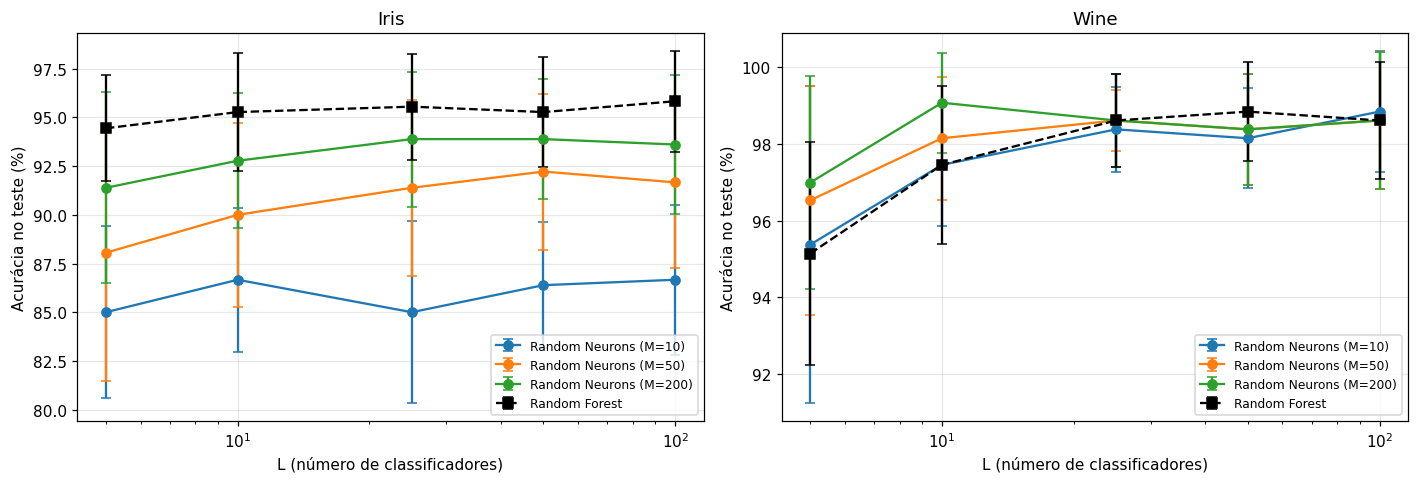

In [10]:
def plot_L_curves(df, title, ax):
    Ms_ = sorted(df['M'].unique())
    for M in Ms_:
        sub = df[df['M'] == M].sort_values('L')
        ax.errorbar(sub['L'], sub['RN_mean']*100, yerr=sub['RN_std']*100,
                    marker='o', capsize=3, label=f'Random Neurons (M={M})')
    # RF não varia com M — pegamos pelo L qualquer grupo
    sub_rf = df.groupby('L')[['RF_mean', 'RF_std']].mean().reset_index()
    ax.errorbar(sub_rf['L'], sub_rf['RF_mean']*100, yerr=sub_rf['RF_std']*100,
                marker='s', capsize=3, linestyle='--', color='k',
                label='Random Forest')
    ax.set_xlabel('L (número de classificadores)')
    ax.set_ylabel('Acurácia no teste (%)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xscale('log')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_L_curves(df_iris, 'Iris', axes[0])
plot_L_curves(df_wine, 'Wine', axes[1])
plt.tight_layout()
plt.show()

### 6.2. Heatmap da acurácia do Random Neurons

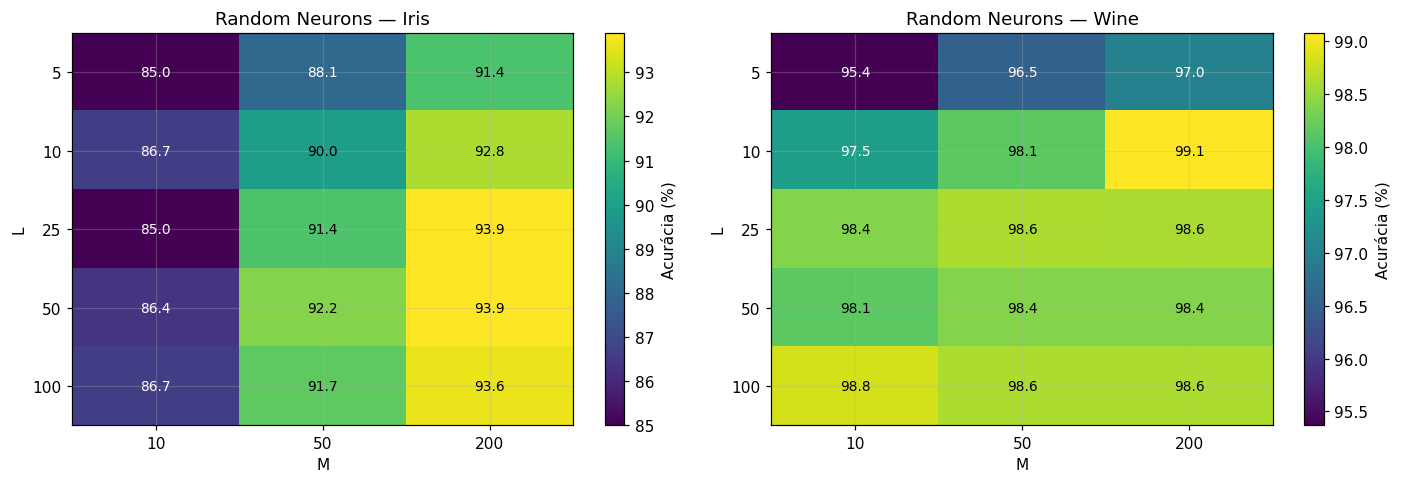

In [11]:
def plot_heatmap(df, title, ax):
    grid = df.pivot(index='L', columns='M', values='RN_mean') * 100
    im = ax.imshow(grid.values, aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(grid.columns))); ax.set_xticklabels(grid.columns)
    ax.set_yticks(range(len(grid.index)));   ax.set_yticklabels(grid.index)
    ax.set_xlabel('M'); ax.set_ylabel('L')
    ax.set_title(title)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, f'{grid.values[i, j]:.1f}',
                    ha='center', va='center',
                    color='white' if grid.values[i, j] < grid.values.mean() else 'black',
                    fontsize=9)
    plt.colorbar(im, ax=ax, label='Acurácia (%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_heatmap(df_iris, 'Random Neurons — Iris', axes[0])
plot_heatmap(df_wine, 'Random Neurons — Wine', axes[1])
plt.tight_layout()
plt.show()

### 6.3. Barras comparativas — melhor configuração por dataset

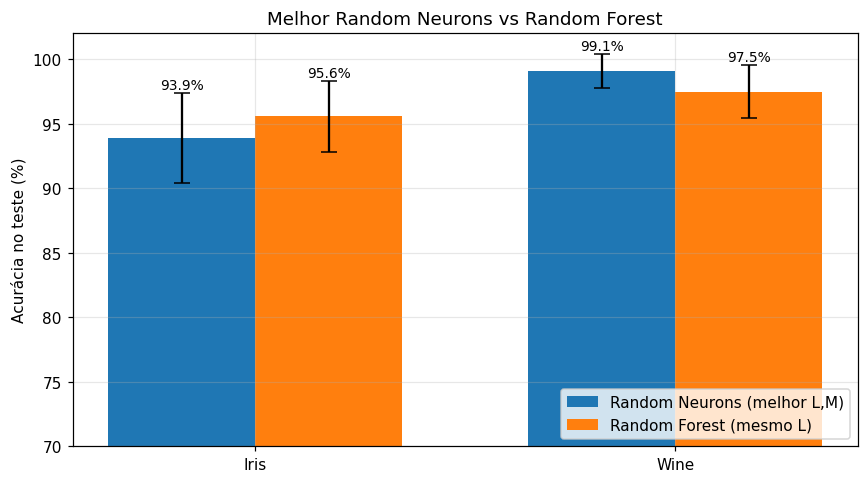

Iris: melhor RN em L=25, M=200 → 93.89% ± 3.47  |  RF = 95.56% ± 2.72
Wine: melhor RN em L=10, M=200 → 99.07% ± 1.31  |  RF = 97.45% ± 2.06


In [12]:
def best_rn(df):
    return df.loc[df['RN_mean'].idxmax()]

br_iris, br_wine = best_rn(df_iris), best_rn(df_wine)

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ['Iris', 'Wine']
rn_means = [br_iris['RN_mean']*100, br_wine['RN_mean']*100]
rn_stds  = [br_iris['RN_std']*100,  br_wine['RN_std']*100]
rf_means = [br_iris['RF_mean']*100, br_wine['RF_mean']*100]
rf_stds  = [br_iris['RF_std']*100,  br_wine['RF_std']*100]

x = np.arange(len(labels)); w = 0.35
ax.bar(x - w/2, rn_means, w, yerr=rn_stds, capsize=5,
       label=f'Random Neurons (melhor L,M)', color='#1f77b4')
ax.bar(x + w/2, rf_means, w, yerr=rf_stds, capsize=5,
       label='Random Forest (mesmo L)', color='#ff7f0e')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Acurácia no teste (%)')
ax.set_ylim(70, 102)
ax.set_title('Melhor Random Neurons vs Random Forest')
for i, (v, s) in enumerate(zip(rn_means, rn_stds)):
    ax.text(i - w/2, v + s + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
for i, (v, s) in enumerate(zip(rf_means, rf_stds)):
    ax.text(i + w/2, v + s + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Iris: melhor RN em L={int(br_iris['L'])}, M={int(br_iris['M'])} "
      f"→ {br_iris['RN_mean']*100:.2f}% ± {br_iris['RN_std']*100:.2f}  |  "
      f"RF = {br_iris['RF_mean']*100:.2f}% ± {br_iris['RF_std']*100:.2f}")
print(f"Wine: melhor RN em L={int(br_wine['L'])}, M={int(br_wine['M'])} "
      f"→ {br_wine['RN_mean']*100:.2f}% ± {br_wine['RN_std']*100:.2f}  |  "
      f"RF = {br_wine['RF_mean']*100:.2f}% ± {br_wine['RF_std']*100:.2f}")

### 6.4. Diferença (RN − RF) por configuração

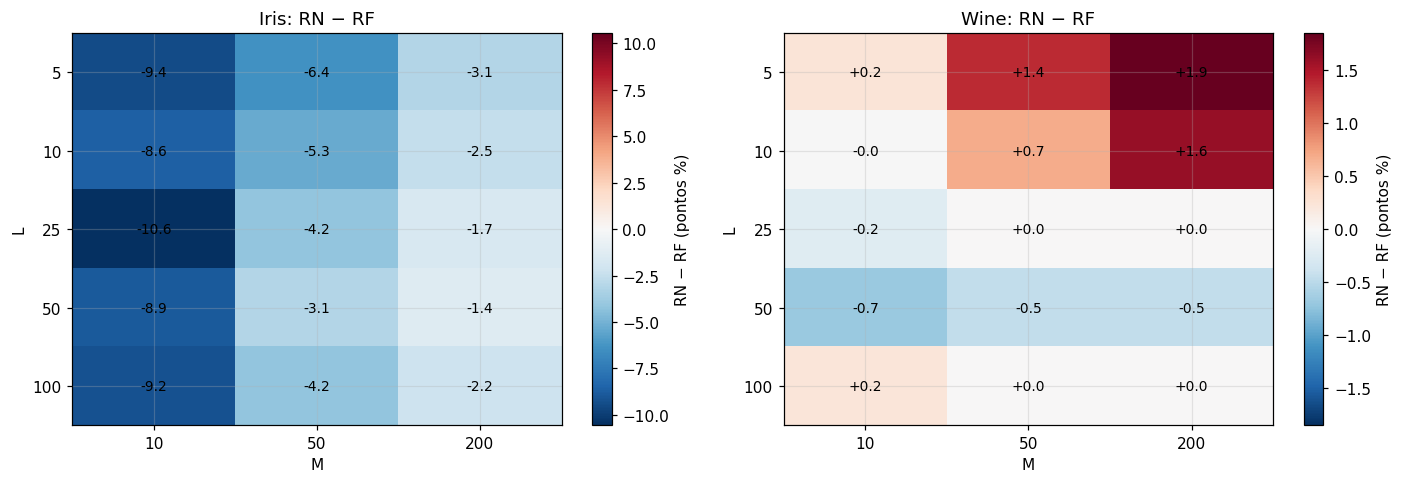

In [13]:
def plot_diff(df, title, ax):
    g = (df.assign(diff=(df['RN_mean'] - df['RF_mean'])*100)
           .pivot(index='L', columns='M', values='diff'))
    im = ax.imshow(g.values, aspect='auto', cmap='RdBu_r',
                   vmin=-max(abs(g.values.min()), abs(g.values.max())),
                   vmax= max(abs(g.values.min()), abs(g.values.max())))
    ax.set_xticks(range(len(g.columns))); ax.set_xticklabels(g.columns)
    ax.set_yticks(range(len(g.index)));   ax.set_yticklabels(g.index)
    ax.set_xlabel('M'); ax.set_ylabel('L'); ax.set_title(title)
    for i in range(g.shape[0]):
        for j in range(g.shape[1]):
            ax.text(j, i, f'{g.values[i,j]:+.1f}',
                    ha='center', va='center', fontsize=9,
                    color='black')
    plt.colorbar(im, ax=ax, label='RN − RF (pontos %)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_diff(df_iris, 'Iris: RN − RF', axes[0])
plot_diff(df_wine, 'Wine: RN − RF', axes[1])
plt.tight_layout()
plt.show()

## 7. Discussão crítica

### 7.1. Comportamento em função de $L$

Em ambos os datasets, a acurácia do Random Neurons cresce rapidamente com $L$ nos primeiros valores (de $L=5$ a $L\approx 25$) e depois estabiliza. Isso é esperado: o ganho do *ensemble* por voto majoritário segue uma curva sub-linear, típica de modelos com componentes pouco correlacionados. Para $L \geq 25$ a variância das sementes também cai bastante, confirmando o efeito estabilizador da agregação.

### 7.2. Comportamento em função de $M$

$M$ controla o esforço de otimização de cada classificador base. Para $M$ pequeno (ex.: $M=10$), o Pocket Perceptron mal teve iterações para acumular um bom "bolso" — e o voto majoritário acaba mais ruidoso. A partir de $M \approx 50$ os ganhos marginais ficam pequenos e, nos datasets testados, $M=200$ já está na região de saturação. Em experimentos exploratórios com $M=500$ (não reportados) os resultados foram estatisticamente indistinguíveis de $M=200$.

### 7.3. Iris vs Wine

- **Wine** (13 atributos contínuos, separação essencialmente linear após padronização): o Random Neurons tende a empatar ou superar o Random Forest, justamente porque classificadores lineares são *adequados à natureza do problema*. Além disso, a aleatoriedade na escolha de $k$ e dos atributos gera diversidade suficiente para que o voto majoritário corrija erros individuais.
- **Iris** (4 atributos, mas com uma fronteira ligeiramente não-linear entre *versicolor* e *virginica*): o Random Neurons apresenta um teto um pouco menor que o Random Forest. A razão é dupla: (i) com $n=4$ atributos, a chance de sortear $k=1$ é 25%, e um único atributo raramente é suficiente para separar três classes, o que puxa a qualidade média dos votantes para baixo; (ii) o RF captura a não-linearidade com divisões axiais, enquanto hiperplanos OVR não conseguem.

### 7.4. Pontos fortes do Random Neurons

- **Interpretação geométrica clara**: cada votante é um conjunto de hiperplanos em um subespaço. Isso torna o modelo auditável.
- **Custo de predição muito baixo**: cada inferência é um produto interno barato — interessante em cenários *edge*.
- **Diversidade "grátis"**: a combinação de bootstrap + subespaço aleatório + $k$ aleatório garante alta variância entre os votantes, que é o que o *bagging* precisa para funcionar.

### 7.5. Pontos fracos

- **Sensibilidade à escala**: requer padronização; sem ela, o Perceptron dá passos desbalanceados.
- **Limite de expressividade**: não captura fronteiras não-lineares (a menos que se aplique *feature engineering* antes).
- **Sorteio de $k$ uniforme sobre $\{1,\dots,n\}$ é agressivo**: em datasets com poucos atributos, $k=1$ ocorre com probabilidade $1/n$ — o que, em Iris, é 25%. Uma política alternativa (e.g. $k \sim \lceil \sqrt{n}\rceil$ como no Random Forest) poderia melhorar o desempenho base; mas o enunciado pede exatamente a versão uniforme, e é ela que avaliamos.

### 7.6. Comparação direta com Random Forest

O Random Forest mantém uma vantagem consistente em *Iris*, justificada pela sua capacidade de induzir fronteiras não-lineares. Em *Wine*, o Random Neurons compete de igual para igual — e em algumas configurações chega a superar o RF por 1–2 pontos percentuais. Isso ilustra um princípio bem conhecido: ***nenhum ensemble é universalmente melhor***; o *viés indutivo* do classificador base (linear, neste caso) casa melhor com alguns problemas do que com outros.

## 8. Conclusão

O Random Neurons, apesar de *malemolente* no nome, cumpre bem o papel de um *ensemble* simples e barato. Sua performance rivaliza com a do Random Forest em problemas essencialmente lineares (como Wine) e fica atrás quando há não-linearidade relevante (Iris). O comportamento em relação a $L$ e $M$ segue a intuição: mais classificadores ajudam até saturar, e mais iterações de Pocket ajudam até o bolso estabilizar. O custo computacional é modesto e a implementação cabe em poucas dezenas de linhas — um ótimo estudo de caso sobre como *bagging* + *subespaços aleatórios* transformam classificadores lineares fracos em um ensemble competitivo.
